# L13b: Self-Attention for Sarcasm Classification in News Headlines
In this lab, we train a multi-head self-attention classifier with positional encoding to detect sarcasm in news headlines from [the Sarcasm Headlines Dataset v2](https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection) and compare its performance against a mean-pooled bag-of-embeddings baseline.

> __Learning Objectives__
>
> By the end of this lab, you should be able to:
>
> * __Build a multi-head self-attention classifier for binary text classification:__ Construct a multi-head scaled dot-product self-attention layer with sinusoidal positional encoding, masked mean-pooling, and a two-layer MLP head to classify headlines as sarcastic or not sarcastic. Connect each component to the attention equations from the L13a lecture.
> * __Train and evaluate on real-world headline data:__ Load real news headlines from the Sarcasm Headlines Dataset v2, embed them as padded GloVe sequences, and train the classifier with cross-entropy loss and the Adam optimizer. Measure test accuracy and confusion matrices on a held-out split.
> * __Visualize attention weights to interpret sarcasm detection:__ Extract the learned attention weight matrices and plot heatmaps on sarcastic headlines to see which tokens the model attends to. Compare the attention model against a mean-pool baseline on the same data.

Let's get started!
___

<div>
    <center>
      <img
        src="figs/Fig-SelfAttention-Block.svg"
        alt="Self-attention block diagram"
        height="600"
        width="900"
      />
    </center>
</div>

## Background: Self-Attention for Text Classification
In the L13a lecture, we introduced the concept of scaled-dot product self-attention and how it can be used to capture contextual relationships between tokens in a sequence. For text classification tasks, we can use self-attention to build a contextual representation of the input text, which is then fed into a classifier to make predictions. 

Let the input to the self-attention layer be a sequence of $n$ token embeddings stacked into a matrix $\mathbf{X}\in\mathbb{R}^{n\times d}$, where $n$ is the sequence length and $d$ is the embedding dimension. Each row $\mathbf{x}_{i}\in\mathbb{R}^{d}$ is the embedding of one token.

Before writing any equations, let's pin down every dimension symbol we will use and where each one comes from.

> __Dimension Dictionary__
>
> _Problem-given (determined by your data and embedding):_
> * $n$ = sequence length (number of tokens in the input). Set by the input sentence or sequence you are processing.
> * $d$ = embedding dimension (width of each token vector). Set by the pretrained embedding you are using, e.g., $d = 300$ for GloVe-300d.
>
> _Design choices (hyperparameters you select):_
> * $d_{k}$ = query/key projection dimension. Controls the width of $\mathbf{Q}$ and $\mathbf{K}$.
> * $d_{v}$ = value projection dimension. Controls the width of $\mathbf{V}$ and the output of a single head.
> * $H$ = number of attention heads (introduced in the next section).
> * $d_{ff}$ = feedforward hidden dimension (introduced with the transformer block).
>
> A common transformer convention is $d_{k} = d_{v} = d/H$, so choosing $H$ also fixes the head dimensions. In this notebook, however, we treat $d_{k}$ and $d_{v}$ as explicit hyperparameters and later set both to 128 to match the implemented model.

The layer first projects $\mathbf{X}$ into three new matrices: queries $\mathbf{Q}$, keys $\mathbf{K}$, and values $\mathbf{V}$.

> __Scaled Dot-Product Self-Attention__
>
> Let the input be $\mathbf{X}\in\mathbb{R}^{n\times d}$ ($n$ tokens, each of dimension $d$, both problem-given). Define three learnable projection matrices:
> * $\mathbf{W}_{Q}\in\mathbb{R}^{d\times d_{k}}$ projects the input to queries (maps from problem-given $d$ (embedding dimension) to chosen $d_{k}$ (query/key dimension))
> * $\mathbf{W}_{K}\in\mathbb{R}^{d\times d_{k}}$ projects the input to keys (maps from problem-given $d$ (embedding dimension) to chosen $d_{k}$ (query/key dimension))
> * $\mathbf{W}_{V}\in\mathbb{R}^{d\times d_{v}}$ projects the input to values (maps from problem-given $d$ (embedding dimension) to chosen $d_{v}$ (value dimension))
>
> The queries, keys, and values are computed as:
> $$
> \boxed{
> \begin{align*}
> \mathbf{Q} &= \mathbf{X}\,\mathbf{W}_{Q} \in \mathbb{R}^{n\times d_{k}} \\
> \mathbf{K} &= \mathbf{X}\,\mathbf{W}_{K} \in \mathbb{R}^{n\times d_{k}} \\
> \mathbf{V} &= \mathbf{X}\,\mathbf{W}_{V} \in \mathbb{R}^{n\times d_{v}}
> \end{align*}}
> $$
> The output of the self-attention layer is:
> $$
> \boxed{
> \operatorname{Attention}(\mathbf{Q},\mathbf{K},\mathbf{V}) = \operatorname{softmax}\!\left(\frac{\mathbf{Q}\mathbf{K}^{\top}}{\sqrt{d_{k}}}\right)\mathbf{V} \in \mathbb{R}^{n\times d_{v}}
> }
> $$
> where the softmax is applied row-wise, so each row of $\mathbf{Q}\mathbf{K}^{\top}/\sqrt{d_{k}}$ is independently normalized to sum to one. Note: we follow the original [Vaswani et al. (2017)](https://arxiv.org/abs/1706.03762) formulation, which uses bias-free projections. Some implementations add bias terms to the projections, but the standard convention omits them.

That compact formula hides the mechanics, so let us unpack it before moving on. The projections $\mathbf{W}_{Q}$, $\mathbf{W}_{K}$, and $\mathbf{W}_{V}$ are learnable parameters that map the input embeddings into three different subspaces, and the dimensions $d_{k}$ and $d_{v}$ control the size of those subspaces.

> __What is the intuition behind the attention output?__
> 
> Inside the $\texttt{softmax}$ operation the matrix $\mathbf{Q}\mathbf{K}^{\top}/\sqrt{d_{k}}$ computes the pairwise similarity between queries and keys, scaled by $\sqrt{d_{k}}$ to prevent large dot products that can drive the softmax into saturation. Substituting the definitions of $\mathbf{Q}$ and $\mathbf{K}$ into the formula gives:
> $$
> \begin{align*}
> \operatorname{Attention}(\mathbf{X}) &= \operatorname{softmax}\!\left(\frac{\mathbf{X}\mathbf{W}_{Q}(\mathbf{X}\mathbf{W}_{K})^{\top}}{\sqrt{d_{k}}}\right)\mathbf{X}\mathbf{W}_{V}\\
> & = \operatorname{softmax}\!\left(\frac{\mathbf{X}\left(\mathbf{W}_{Q}\mathbf{W}_{K}^{\top}\right)\mathbf{X}^{\top}}{\sqrt{d_{k}}}\right)\mathbf{X}\mathbf{W}_{V}
> \end{align*}
> $$
> This shows that the attention output is a weighted sum of the value projections $\mathbf{X}\mathbf{W}_{V}$, where the weights are determined by the similarity between the query and key projections of the input. Each output token attends to all input tokens, allowing the model to capture long-range dependencies and contextual relationships in the input sequence.
>
> To see why the learned matrix $\mathbf{W}_{Q}\mathbf{W}_{K}^{\top}$ matters, consider the trivial case where $\mathbf{W}_{Q}\mathbf{W}_{K}^{\top} = \mathbf{I}$. The score matrix collapses to the **Gram matrix** of the input embeddings:
> $$
> \mathbf{Q}\mathbf{K}^{\top} = \mathbf{X}\mathbf{I}\,\mathbf{X}^{\top} = \mathbf{X}\mathbf{X}^{\top}
> $$
> with entry $(i, j)$ equal to $\langle\mathbf{x}_{i}, \mathbf{x}_{j}\rangle$, the raw inner product between token $i$ and token $j$. In this case, attention reduces to "each token attends to other tokens based purely on embedding similarity in the input space" -- semantically similar GloVe tokens would attend to each other automatically. The learned matrix $\mathbf{M} = \mathbf{W}_{Q}\mathbf{W}_{K}^{\top}\in\mathbb{R}^{d\times d}$ generalizes this to a learned bilinear form $\langle\mathbf{x}_{i}, \mathbf{x}_{j}\rangle_{\mathbf{M}} = \mathbf{x}_{i}^{\top}\mathbf{M}\,\mathbf{x}_{j}$, letting each head define its own notion of "relatedness" beyond plain embedding similarity. Note also that $\mathbf{M}$ is generally **not symmetric**, so attention is _directional_: token $i$ attending to $j$ is not the same as $j$ attending to $i$, which lets attention encode asymmetric relationships like "subject points to verb."

Now that we understand what the bilinear form $\mathbf{Q}\mathbf{K}^{\top}/\sqrt{d_{k}}$ measures, the next question is what the softmax does to it.

> __What is the softmax doing?__
>
> The score matrix $\mathbf{S} = \mathbf{Q}\mathbf{K}^{\top}/\sqrt{d_{k}}\in\mathbb{R}^{n\times n}$ has element $s_{ij}$ equal to:
> $$
> s_{ij} = \frac{\langle \mathbf{q}_{i}, \mathbf{k}_{j}\rangle}{\sqrt{d_{k}}}
> $$
> i.e., the **scaled similarity score** between query vector $\mathbf{q}_{i}$ (from token $i$) and key vector $\mathbf{k}_{j}$ (from token $j$). The division by $\sqrt{d_{k}}$ is a _magnitude_ normalization that prevents the dot products from growing large with $d_{k}$ (which would push the softmax into saturation, with all weight on a single token). It is **not** a probability normalization, the entries of $\mathbf{S}$ are real numbers that can be positive or negative and do not sum to anything in particular. The softmax, applied row-wise, is what converts these scaled scores into a proper probability distribution $\mathbf{P}\in\mathbb{R}^{n\times n}$ with entries:
> $$
> p_{ij} = \frac{\exp(s_{ij})}{\sum_{k=1}^{n}\exp(s_{ik})}, \qquad \sum_{j=1}^{n} p_{ij} = 1
> $$
> So each **row** $\mathbf{p}_{i,:}$ is a probability distribution over the $n$ tokens. The entry $p_{ij}$ is the weight that token $i$ assigns to token $j$ when computing token $i$'s updated representation. In shorthand, we say "token $i$ attends to token $j$" (meaning $p_{ij}$ is large, so token $j$'s value vector contributes heavily to token $i$'s output) and "token $i$ ignores token $j$" (meaning $p_{ij}$ is near zero). These phrases are purely mechanical; there is no cognitive process, just a learned weighted average.
>
> Before writing the output, let us be precise about what the value vectors are. The value matrix $\mathbf{V} = \mathbf{X}\mathbf{W}_{V}\in\mathbb{R}^{n\times d_{v}}$ has the same row layout as the input $\mathbf{X}$: there is **one row per token**. The $j$-th row, written $\mathbf{v}_{j}\in\mathbb{R}^{d_{v}}$, is a $d_{v}$-dimensional vector that is **token $j$ projected into the value subspace** by the learned matrix $\mathbf{W}_{V}$. The three projections $\mathbf{q}_{j}$, $\mathbf{k}_{j}$, $\mathbf{v}_{j}$ are three different learned views of the same token, and they play distinct mechanical roles:
>
> * $\mathbf{q}_{j}$ and $\mathbf{k}_{j}$ (query and key) are used **only** to compute the attention weights $p_{ij}$ via their dot products. They never appear in the output directly.
> * $\mathbf{v}_{j}$ (value) is the actual content that flows into the output. It is the piece of token $j$ that gets mixed into other tokens' representations.
>
> The output for token $i$ is a convex combination of all the value vectors, weighted by the attention weights in row $i$ of $\mathbf{P}$:
> $$
> \mathbf{y}_{i} = \sum_{j=1}^{n} p_{ij}\,\mathbf{v}_{j}
> $$
> So $\mathbf{y}_{i}$ is token $i$'s new representation, built by taking a weighted blend of every token's value vector, with the weights coming from row $i$ of $\mathbf{P}$.
>
> A few things to notice:
> * $p_{ii}$ is the weight token $i$ places on its own value vector. A high diagonal in $\mathbf{P}$ means tokens mostly retain their original (value-projected) information rather than mixing in content from other tokens.
> * $p_{ij}$ for $i\neq j$ is the weight with which token $j$'s content enters token $i$'s output. Off-diagonal entries are where contextual mixing happens.
> * The matrix $\mathbf{P}$ is generally **not symmetric**: $p_{ij}\neq p_{ji}$, since $\mathbf{W}_{Q}\mathbf{W}_{K}^{\top}$ is not symmetric. The weight token $i$ places on token $j$ is a separate number from the weight token $j$ places on token $i$.
>
> This is what the heatmaps later in the lab show: the y-axis is the query index $i$ (which row of $\mathbf{P}$), the x-axis is the key index $j$ (which column), and the color at cell $(i, j)$ encodes the value of $p_{ij}$. A bright cell at $(i, j)$ means $p_{ij}$ is large, i.e., token $j$'s value vector contributes heavily to token $i$'s updated representation.

### From self-attention to a classifier
Self-attention gives us a new matrix $\mathbf{Y}\in\mathbb{R}^{n\times d_{v}}$ of context-aware token representations: one row per input token, each row updated by a weighted blend of value vectors from the whole sequence. But for sarcasm classification we need a single prediction for the entire headline, not $n$ separate token-level outputs. We therefore collapse $\mathbf{Y}$ into a single vector and pass it through a small classifier head.

> __The full pipeline: headline $\rightarrow$ class logits__
>
> Starting from a padded single headline tokenized and embedded as $\mathbf{X}\in\mathbb{R}^{n\times d}$ with a boolean mask $\mathbf{m}\in\{0,1\}^{n}$ marking valid (non-padding) positions:
>
> 1. **Add positional encoding**: $\tilde{\mathbf{X}} = \mathbf{X} + \mathbf{P}$, where $\mathbf{P}\in\mathbb{R}^{n\times d}$ is a fixed sinusoidal matrix that gives the model information about token position (self-attention alone is permutation-equivariant).
> 2. **Multi-head self-attention**: $\mathbf{Y} = \operatorname{MHA}(\tilde{\mathbf{X}}, \mathbf{m})\in\mathbb{R}^{n\times d_{v}}$. Each head computes $\operatorname{softmax}(\mathbf{Q}^{(h)}(\mathbf{K}^{(h)})^{\top}/\sqrt{d_{k}})\,\mathbf{V}^{(h)}$, outputs are concatenated along the feature dimension, and projected through $\mathbf{W}_{O}$ back to dimension $d_{v}$.
> 3. **Masked mean-pool** (collapse $n$ tokens $\rightarrow$ $1$ vector): $\mathbf{z} = \frac{1}{\sum_{i} m_{i}}\sum_{i=1}^{n} m_{i}\,\mathbf{y}_{i}\in\mathbb{R}^{d_{v}}$. We average the rows of $\mathbf{Y}$ but only over valid (non-padding) positions, so short headlines are not penalized by padding zeros.
> 4. **MLP head** (map pooled vector to class scores): first compute a hidden representation $\mathbf{h} = \operatorname{ReLU}(\mathbf{W}_{1}\mathbf{z} + \mathbf{b}_{1})\in\mathbb{R}^{d_{\text{hidden}}}$. During training, the implementation applies dropout to $\mathbf{h}$ before the final linear map $\boldsymbol{\ell} = \mathbf{W}_{2}\mathbf{h} + \mathbf{b}_{2}\in\mathbb{R}^{C}$, where $C$ is the number of classes ($C = 2$ here: not_sarcastic vs. sarcastic).
> 5. **Softmax + cross-entropy loss** (training only): the predicted class probabilities are $\hat{\mathbf{p}} = \operatorname{softmax}(\boldsymbol{\ell})$, and the loss for a headline with true one-hot label $\mathbf{y}\in\{0,1\}^{C}$ is $\mathcal{L} = -\sum_{c=1}^{C} y_{c}\log \hat{p}_{c}$. At prediction time we just take $\arg\max_{c}\ell_{c}$.
>
> The learnable parameters are $\{\mathbf{W}_{Q}^{(h)}, \mathbf{W}_{K}^{(h)}, \mathbf{W}_{V}^{(h)}\}_{h=1}^{H}$, $\mathbf{W}_{O}$, $\mathbf{W}_{1}, \mathbf{b}_{1}$, $\mathbf{W}_{2}, \mathbf{b}_{2}$. The positional encoding $\mathbf{P}$ is **fixed**, not trained. Gradients from the cross-entropy loss flow back through the MLP head, the mean-pool, and into every projection matrix, which is how the attention weights learn to concentrate on sarcasm-relevant token relationships.

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, loading any needed resources, such as sample datasets, and setting up any required constants.

> __What is the `Include.jl` file?__
>
> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file in the global scope of the containing module. The `Include.jl` file loads all required packages and source files.

We start by loading the local environment and the helper code used throughout the lab.

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b`


In addition to standard Julia libraries, this lab uses [the `Flux.jl` package](https://fluxml.ai/Flux.jl/stable/) for neural network layers and gradient-based optimization, [`NNlib.jl`](https://github.com/FluxML/NNlib.jl) for batched matrix operations and softmax, [`OneHotArrays.jl`](https://github.com/FluxML/OneHotArrays.jl) for one-hot label encoding, [`JSON.jl`](https://github.com/JuliaIO/JSON.jl) for parsing the JSONL dataset, [`JLD2.jl`](https://github.com/JuliaIO/JLD2.jl) for model checkpointing, [`Plots.jl`](https://docs.juliaplots.org/stable/) for visualization, and [`PrettyTables.jl`](https://github.com/ronisbr/PrettyTables.jl) for formatted table output.

### Data
We use [Stanford GloVe 6B 300-dimensional embeddings](https://nlp.stanford.edu/projects/glove/) for word representations. The [Sarcasm Headlines Dataset v2](https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection) contains 28,619 news headlines from The Onion (sarcastic) and HuffPost (not sarcastic) in JSONL format with fields `is_sarcastic`, `headline`, and `article_link`.

We first load the GloVe embeddings, then parse the sarcasm dataset.

In [2]:
# check: do we have a local copy of the GloVe embeddings? If not, download them.
glove_path = joinpath(_PATH_TO_DATA, "glove.6B.300d.txt");
isfile(glove_path) || (glove_path = download_glove(_PATH_TO_DATA; dim=300));
glove = load_glove_embeddings(glove_path);
@info "GloVe loaded" n_words=length(glove) dim=length(first(values(glove)));

┌ Info: GloVe loaded
│   n_words = 400000
│   dim = 300
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y203sZmlsZQ==.jl:5


Next, we load the sarcasm headlines from the JSONL file into a DataFrame. The result is stored in the `headlines_df::DataFrame` variable, which has two columns: `headline::String` (the text of each headline) and `is_sarcastic::Int` (binary label, 1 if sarcastic, 0 otherwise).

In [3]:
headlines_df = let

    # parse each line of the JSONL file into a vector of dictionaries
    records = Vector{Dict{String,Any}}();
    open(joinpath(_PATH_TO_DATA, "Sarcasm_Headlines_Dataset_v2.txt")) do f
        for line in eachline(f)
            push!(records, JSON.parse(line));
        end
    end

    # build DataFrame with headline text and integer sarcasm label
    DataFrame(
        headline = String[r["headline"] for r in records],
        is_sarcastic = Int[r["is_sarcastic"] for r in records]
    )
end;
@info "Headlines loaded" n=nrow(headlines_df);
class_counts = combine(groupby(headlines_df, :is_sarcastic), nrow => :count);
pretty_table(class_counts)

┌ Info: Headlines loaded
│   n = 28619
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y205sZmlsZQ==.jl:17


┌──────────────┬───────┐
│ is_sarcastic │ count │
│        Int64 │ Int64 │
├──────────────┼───────┤
│            0 │ 14985 │
│            1 │ 13634 │
└──────────────┴───────┘


### Implementations
We use helper functions defined in this notebook and in the `src/` directory:

| Function | Source | Description |
| --- | --- | --- |
| `confusion_matrix(...)` | notebook | Build a confusion matrix from true and predicted label indices |
| `plot_attention(...)` | notebook | Extract attention weights and render as a heatmap |
| [`sinusoidal_pe(...)`](src/Attention.jl) | `src/Attention.jl` | Compute sinusoidal positional encoding matrix |
| [`SelfAttention(...)`](src/Attention.jl) | `src/Attention.jl` | Single-head scaled dot-product self-attention layer |
| [`MultiHeadAttention(...)`](src/Attention.jl) | `src/Attention.jl` | Multi-head self-attention with output projection |
| [`AttentionClassifier(...)`](src/Attention.jl) | `src/Attention.jl` | PE + multi-head attention + masked mean-pool + MLP head |
| [`embed_reviews_sequence(...)`](src/Embeddings.jl) | `src/Embeddings.jl` | Embed text as padded GloVe token sequences |
| [`embed_reviews(...)`](src/Embeddings.jl) | `src/Embeddings.jl` | Embed text as mean-pooled GloVe vectors (baseline) |
| [`load_glove_embeddings(...)`](src/GloVeUtils.jl) | `src/GloVeUtils.jl` | Load GloVe word vectors from text file |

In [4]:
"""Build a confusion matrix C where C[t, p] counts how many times true class t was predicted as class p."""
function confusion_matrix(y_true_idx::Vector{Int}, y_pred_idx::Vector{Int}, n_classes::Int)
    C = zeros(Int, n_classes, n_classes); # initialize n_classes × n_classes matrix of zeros
    for (t, p) in zip(y_true_idx, y_pred_idx)
        C[t, p] += 1; # increment the count for (true class t, predicted class p)
    end
    return C;
end

confusion_matrix

Next, we define the attention visualization function. This function extracts the attention weight matrix from the trained model and renders it as a heatmap.

In [5]:
"""Extract the attention weight matrix from a trained model and render it as a heatmap."""
function plot_attention(model::AttentionClassifier, X_one::AbstractArray{<:Real, 3},
                          mask_one::AbstractMatrix{Bool}, tokens_one::Vector{String};
                          title_str::String="attention")

    w = attention_weights(model, X_one, mask_one);              # (n, n, 1) attention weight tensor
    n_valid = sum(mask_one);                                     # number of real (non-padding) tokens
    A = collect(Float64.(w[1:n_valid, 1:n_valid, 1]));          # extract the valid region as a dense matrix
    toks = tokens_one[1:n_valid];                                # token strings for axis labels

    # plot: use integer axes with manual tick labels to avoid Plots.jl sorting strings alphabetically
    heatmap(1:n_valid, 1:n_valid, A;
            xticks=(1:n_valid, toks), yticks=(1:n_valid, toks),
            xlabel="key (attended-to token)",
            ylabel="query (attending token)",
            title=title_str,
            xrotation=60, color=:viridis,
            size=(700, 600), yflip=true)
end;

We also define a function to visualize individual attention heads. The `plot_attention` function above shows the average across all heads. To understand what each head has learned, we need to inspect them one at a time.

In [6]:
"""Visualize the attention pattern for a single head (specified by `head_index`, 1-based)."""
function plot_attention_head(model::AttentionClassifier, X_one::AbstractArray{<:Real, 3},
                              mask_one::AbstractMatrix{Bool}, tokens_one::Vector{String};
                              head_index::Int=1, title_str::String="attention")

    all_weights = per_head_attention_weights(model, X_one, mask_one);  # vector of (n, n, 1) arrays
    n_valid = sum(mask_one);
    A = collect(Float64.(all_weights[head_index][1:n_valid, 1:n_valid, 1]));
    toks = tokens_one[1:n_valid];

    panel_title = isempty(title_str) ? "head $(head_index)" : "$(title_str) — head $(head_index)"
    heatmap(1:n_valid, 1:n_valid, A;
            xticks=(1:n_valid, toks), yticks=(1:n_valid, toks),
            xlabel="key (attended-to token)",
            ylabel="query (attending token)",
            title=panel_title,
            xrotation=60, color=:viridis,
            size=(700, 600), yflip=true)
end;

### Constants
We define constants used throughout the lab. The embedding dimension `D_EMB` matches the GloVe vector size, and the maximum sequence length `N_MAX` controls padding and truncation of each headline. We set `N_MAX = 20` to keep the padded sequences manageable while still preserving many headline-length examples.

We embed each headline as a padded sequence of GloVe vectors stored in `X_seq`, with a boolean padding mask in `mask` and per-headline token strings in `tokens_str`.

In [7]:
const D_EMB = 300;   # GloVe embedding dimension (300d for richer token representations)
const N_MAX = 20;    # max sequence length (pad or truncate each headline to this length)

# embed each headline as a padded sequence of GloVe vectors
X_seq, mask, tokens_str = embed_reviews_sequence(
    string.(headlines_df.headline), glove; dim=D_EMB, n_max=N_MAX);
@info "Padded sequences" X_shape=size(X_seq) mask_shape=size(mask)

┌ Info: Padded sequences
│   X_shape = (300, 20, 28619)
│   mask_shape = (20, 28619)
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y216sZmlsZQ==.jl:7


Next, we encode the binary labels (not sarcastic / sarcastic) as integer indices and one-hot vectors. The label mapping follows the order `["not_sarcastic", "sarcastic"]` so that index 1 corresponds to not sarcastic and index 2 corresponds to sarcastic.

In [8]:
const CLASS_NAMES = ["not_sarcastic", "sarcastic"];
const N_CLASSES = length(CLASS_NAMES);

# map is_sarcastic (0/1) to class index (1/2): 0 → 1 (not_sarcastic), 1 → 2 (sarcastic)
y_idx = headlines_df.is_sarcastic .+ 1;
y_onehot = Float32.(Flux.onehotbatch(y_idx, 1:N_CLASSES));

We then take an 80/20 train/test split. The training and test tensors are stored in `X_train_seq`, `mask_train`, `y_train` and `X_test_seq`, `mask_test`, `y_test`. The index arrays `TRAIN_IDX` and `TEST_IDX` store which headlines belong to each split, for use when comparing against the baseline.

In [9]:
X_train_seq, mask_train, y_train, X_test_seq, mask_test, y_test, TRAIN_IDX, TEST_IDX = let

    # shuffle and split into 80% train / 20% test
    Random.seed!(42);
    N = size(X_seq, 3);
    perm = randperm(N);
    n_train = round(Int, 0.8 * N);
    train_idx = perm[1:n_train];
    test_idx  = perm[n_train+1:end];

    X_train_seq = X_seq[:, :, train_idx];
    mask_train  = mask[:, train_idx];
    y_train     = y_onehot[:, train_idx];
    X_test_seq  = X_seq[:, :, test_idx];
    mask_test   = mask[:, test_idx];
    y_test      = y_onehot[:, test_idx];

    @info "Train/test split" n_train=size(X_train_seq, 3) n_test=size(X_test_seq, 3)

    # return -
    (X_train_seq, mask_train, y_train, X_test_seq, mask_test, y_test, train_idx, test_idx)
end;

┌ Info: Train/test split
│   n_train = 22895
│   n_test = 5724
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y223sZmlsZQ==.jl:18


___

## Task 1: Build the Self-Attention Classifier
In this task, we will build a self-attention classifier using the components defined in [src/Attention.jl](src/Attention.jl). Let's review the architecture of the model and how each component connects to the attention equations.

> __Architecture__
>
> * __Sinusoidal positional encoding__: added to the GloVe token embeddings before attention. Self-attention is permutation-equivariant, so without positional encoding the model has no sense of word order. Sarcasm often depends on word positioning, so this information matters.
> * __Multi-head self-attention__: instead of a single attention head, we use multiple heads in parallel, each with its own learned projection matrices $\mathbf{W}_{Q}^{(h)}$, $\mathbf{W}_{K}^{(h)}$, $\mathbf{W}_{V}^{(h)}$. Each head independently computes $\text{softmax}(\mathbf{Q}^{(h)}(\mathbf{K}^{(h)})^{\top}/\sqrt{d_{k}})\,\mathbf{V}^{(h)}$, so different heads can learn to attend to different types of token relationships. For example, one head might learn to link subjects to verbs, while another focuses on adjective-noun incongruities that signal sarcasm. The heads' outputs are concatenated and projected through a learned output matrix $\mathbf{W}_{O}$.
> * __Masked mean-pooling__: averages the attention output over non-padding positions to produce a single fixed-size vector per headline.
> * __MLP head__: a two-layer feed-forward network with dropout ([`Dense`](https://fluxml.ai/Flux.jl/stable/reference/models/layers/#Flux.Dense) $\rightarrow$ `relu` $\rightarrow$ [`Dropout`](https://fluxml.ai/Flux.jl/stable/reference/models/layers/#Flux.Dropout) $\rightarrow$ [`Dense`](https://fluxml.ai/Flux.jl/stable/reference/models/layers/#Flux.Dense)) that maps the pooled vector to 2-class logits (not sarcastic vs. sarcastic).

We initialize the model with $d_{k} = d_{v} = 128$, $n_{\text{heads}} = 10$, and hidden layer width $d_{\text{hidden}} = 64$. Using 10 heads means the model has 10 independent sets of projection matrices, each producing its own attention pattern over the input tokens.

The built model is stored in the `model::AttentionClassifier` variable. The total trainable parameter count is stored in `n_params::Int`, and the MLP hidden-layer width is stored in `D_HIDDEN::Int` for reuse when building the baseline model in Task 3.

In [10]:
model, n_params, D_HIDDEN = let

    # initialize - set the projection and hidden dimensions
    d_k = 128;          # query/key projection dimension per head
    d_v = 128;          # value projection dimension per head
    n_heads = 10;       # number of parallel attention heads
    d_hidden = 64;      # MLP hidden layer width (used later for baseline)

    # build the multi-head self-attention classifier with positional encoding and dropout
    Random.seed!(42);
    model = AttentionClassifier(D_EMB, d_k, d_v, n_heads, d_hidden, N_CLASSES;
                                n_max=N_MAX, dropout=0.3);
    n_params = sum(length, Flux.trainables(model)); # count total trainable parameters
    @info "multi-head self-attention classifier" n_params=n_params d_emb=D_EMB d_k=d_k d_v=d_v n_heads=n_heads d_hidden=d_hidden n_classes=N_CLASSES dropout=0.3

    # return -
    (model, n_params, d_hidden)
end;

┌ Info: multi-head self-attention classifier
│   n_params = 1324226
│   d_emb = 300
│   d_k = 128
│   d_v = 128
│   n_heads = 10
│   d_hidden = 64
│   n_classes = 2
│   dropout = 0.3
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y226sZmlsZQ==.jl:14


### Things to think about
* __Where is the parameter count concentrated?__ The build step prints `n_params` via `@info`. Without running any additional code, estimate the parameter count contributed by each piece of the architecture: the 10 attention heads (3 projection matrices each of shape $d\times d_{k} = 300\times 128$), the output matrix $\mathbf{W}_{O}$ of shape $(H\cdot d_{v})\times d_{v} = 1280\times 128$, and the MLP head $d_{v}\rightarrow d_{\text{hidden}}\rightarrow C = 128\rightarrow 64\rightarrow 2$. Is most of the parameter count in the attention projections or the MLP head?

___

## Task 2: Train the Self-Attention Classifier
In this task, we train the self-attention classifier with Adam at learning rate $3\times 10^{-3}$ for 100 epochs with batch size 128. The first run trains the model and saves a checkpoint to `data/attention_sarcasm_H64.jld2`; subsequent runs load that saved checkpoint to skip retraining. If we change the model architecture or training setup, we can delete the checkpoint file to force a fresh run.

> __Training details__
>
> The loss function is logit cross-entropy ([`Flux.logitcrossentropy`](https://fluxml.ai/Flux.jl/stable/reference/models/losses/#Flux.Losses.logitcrossentropy)), which combines softmax and cross-entropy in a numerically stable way. We use mini-batch gradient-based optimization with Adam, and the training indices are reshuffled each epoch.

We save the final trained model state and the per-epoch training loss history to a JLD2 file. This notebook does not use a separate validation split, so the checkpoint is the final model from the training run rather than a validation-selected best model. The `train_loss_history` vector stores the average training loss at each epoch.

In [11]:
train_loss_history = let

    # initialize -
    checkpoint_path = joinpath(_PATH_TO_DATA, "attention_sarcasm_H64.jld2");
    n_epochs = 100;      # number of training epochs
    batchsize = 128;      # mini-batch size for SGD
    train_loss_history = Float32[];

    if isfile(checkpoint_path)
        # checkpoint exists: load saved model weights and loss history instead of retraining
        @info "Loading pre-trained checkpoint" path=checkpoint_path
        saved = JLD2.load(checkpoint_path);
        Flux.loadmodel!(model, saved["model_state"]);
        train_loss_history = saved["train_loss_history"];
        @info "Loaded model from checkpoint"
    else
        # no checkpoint: train from scratch with Adam optimizer
        @info "No checkpoint found, training from scratch..."
        Random.seed!(42);
        opt = Flux.setup(Adam(3.0f-3), model); # Adam optimizer with learning rate 3e-3
        n_tr = size(X_train_seq, 3);           # number of training headlines

        for epoch in 1:n_epochs
            epoch_losses = Float32[];
            perm_e = randperm(n_tr); # shuffle training indices each epoch

            # mini-batch training loop
            for i in 1:batchsize:n_tr
                idxs = perm_e[i:min(i + batchsize - 1, n_tr)]; # batch indices
                Xb = X_train_seq[:, :, idxs];   # batch token sequences
                mb = mask_train[:, idxs];         # batch masks
                yb = y_train[:, idxs];            # batch one-hot labels

                # compute loss and gradients, then update model parameters
                l, gs = Flux.withgradient(model) do m
                    Flux.logitcrossentropy(m(Xb, mb), yb)
                end
                push!(epoch_losses, l);
                Flux.update!(opt, model, gs[1]);
            end

            push!(train_loss_history, mean(epoch_losses));

            # log train/test accuracy every 5 epochs (and epoch 1)
            if epoch == 1 || epoch % 5 == 0
                tr_logits = model(X_train_seq, mask_train);
                tr_acc = mean(Flux.onecold(tr_logits) .== Flux.onecold(y_train));
                te_logits = model(X_test_seq, mask_test);
                te_acc = mean(Flux.onecold(te_logits) .== Flux.onecold(y_test));
                @info "epoch" epoch loss=round(mean(epoch_losses), digits=4) train_acc=round(tr_acc, digits=3) test_acc=round(te_acc, digits=3)
            end
        end

        # save checkpoint so we can skip training on future runs
        JLD2.jldsave(checkpoint_path; model_state = Flux.state(model), train_loss_history = train_loss_history);
        @info "Saved checkpoint" path=checkpoint_path
    end

    # return -
    train_loss_history
end;

┌ Info: Loading pre-trained checkpoint
│   path = /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/data/attention_sarcasm_H64.jld2
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y233sZmlsZQ==.jl:11
┌ Info: Loaded model from checkpoint
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y233sZmlsZQ==.jl:15


The per-epoch average training loss values are stored in `train_loss_history`. Let's plot the training loss to verify that the model converges.

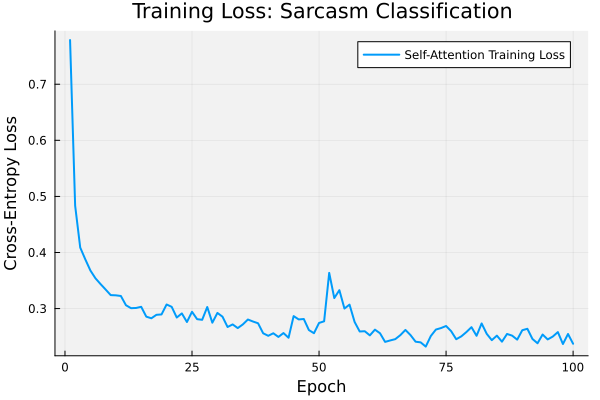

In [12]:
let
    # plot per-epoch training loss to verify convergence
    plot(1:length(train_loss_history), train_loss_history;
         xlabel="Epoch", ylabel="Cross-Entropy Loss",
         label="Self-Attention Training Loss",
         lw=2, legend=:topright,
         background_color_inside=:gray95,
         title="Training Loss: Sarcasm Classification")
end

### Things to think about
* __Is the model converged?__ Look at the training loss curve plotted above. Does the loss flatten out by epoch 30, or is it still decreasing? Based on the shape of the curve alone (no retraining), would running additional epochs plausibly help test accuracy or push the model into overfitting on the training set?

___

## Task 3: Evaluate and Compare with Baseline
In this task, we compute test accuracy and a confusion matrix to see how well the self-attention model distinguishes sarcastic from non-sarcastic headlines. Then we train the mean-pool baseline on the same split for a direct comparison. Finally, we visualize the attention weights on example headlines to interpret what the model has learned.

> __What is the baseline?__
>
> The baseline is a **mean-pooled bag-of-embeddings classifier**. For each headline, we look up the GloVe vector for each in-vocabulary token and average those vectors into a single fixed-length representation. This preserves coarse word-content information, but it discards word order and any token-to-token interaction structure.
>
> We then feed that mean GloVe vector into a two-layer MLP (`Dense` $\rightarrow$ `relu` $\rightarrow$ `Dense`) to predict the sarcasm label. We train and evaluate this baseline on the **same train/test split** as the self-attention model so that we can compare a sequence-aware model against a simple order-agnostic reference on the same data.

With that reference model defined, we can now evaluate both models on the held-out test set.

> __Evaluation__
>
> We use [`Flux.onecold`](https://fluxml.ai/Flux.jl/stable/reference/models/nnlib/#NNlib.onecold) to convert logits to predicted class indices, compute accuracy as the fraction of correct predictions, and build a confusion matrix to summarize the error pattern for each model.

We compute predictions on the held-out test set and build a confusion matrix. The predicted class indices are stored in `test_pred::Vector{Int}`, the ground-truth indices in `test_true::Vector{Int}`, the overall test accuracy in `test_acc::Float64`, the $C\times C$ confusion matrix in `C_attn::Matrix{Int}`, and the class name labels for the confusion-matrix axes in `cm_labels::Vector{String}`.

In [13]:
test_pred, test_true, test_acc, C_attn, cm_labels = let

    # compute predictions on the held-out test set
    test_logits = model(X_test_seq, mask_test);               # (n_classes, n_test) logits
    test_pred = Flux.onecold(test_logits);              # predicted class indices
    test_true = Flux.onecold(y_test);                   # true class indices
    test_acc = mean(test_pred .== test_true);           # test accuracy
    @info "self-attention test accuracy" acc=round(test_acc, digits=4)

    # build and display the confusion matrix (rows = true class, cols = predicted class)
    C_attn = confusion_matrix(test_true, test_pred, N_CLASSES);
    cm_labels = ["true \\ pred"; CLASS_NAMES];
    println("Confusion matrix (rows = true, cols = predicted):");
    rows = [[CLASS_NAMES[i]; C_attn[i, :]] for i in 1:N_CLASSES];
    pretty_table(reduce(vcat, [permutedims(r) for r in rows]); column_labels=cm_labels)

    # return -
    (test_pred, test_true, test_acc, C_attn, cm_labels)
end;

┌ Info: self-attention test accuracy
│   acc = 0.8139
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y242sZmlsZQ==.jl:8


Confusion matrix (rows = true, cols = predicted):
┌───────────────┬───────────────┬───────────┐
│  true \\ pred │ not_sarcastic │ sarcastic │
├───────────────┼───────────────┼───────────┤
│ not_sarcastic │          2678 │       303 │
│     sarcastic │           762 │      1981 │
└───────────────┴───────────────┴───────────┘


Now we train the mean-pool baseline on the same train/test indices for a direct comparison. We first re-embed the headlines as mean-pooled GloVe vectors.

In [14]:
# re-embed headlines as mean-pooled vectors (bag-of-embeddings baseline)
X_mean = embed_reviews(string.(headlines_df.headline), glove; dim=D_EMB); # (d, N) matrix
X_train_mean = X_mean[:, TRAIN_IDX];
X_test_mean  = X_mean[:, TEST_IDX];

Next, we train the baseline model on the same split and evaluate its test accuracy. The trained baseline model is stored in `baseline::Chain`, its parameter count in `n_baseline_params::Int`, the per-epoch training loss history in `baseline_loss_history::Vector{Float64}`, the test-set class predictions in `baseline_pred::Vector{Int}`, and the test accuracy in `baseline_acc::Float64`.

In [15]:
baseline, n_baseline_params, baseline_loss_history, baseline_pred, baseline_acc = let

    # build the mean-pool baseline: same MLP head architecture, but input is a single mean vector
    Random.seed!(42);
    baseline = Chain(Dense(D_EMB => D_HIDDEN, relu), Dense(D_HIDDEN => N_CLASSES));
    n_baseline_params = sum(length, Flux.trainables(baseline));
    @info "mean-pool baseline" n_params=n_baseline_params

    # train with Adam on the same train/test split using a lightweight baseline schedule
    n_epochs = 30;
    batchsize = 32;
    opt_b = Flux.setup(Adam(3.0f-3), baseline);
    baseline_loss_history = Float32[];
    n_tr = size(X_train_mean, 2);

    for epoch in 1:n_epochs
        epoch_losses = Float32[];
        perm_e = randperm(n_tr); # shuffle each epoch
        for i in 1:batchsize:n_tr
            idxs = perm_e[i:min(i + batchsize - 1, n_tr)];
            Xb = X_train_mean[:, idxs];  # batch of mean-pooled vectors
            yb = y_train[:, idxs];        # batch of one-hot labels
            l, gs = Flux.withgradient(baseline) do m
                Flux.logitcrossentropy(m(Xb), yb)
            end
            push!(epoch_losses, l);
            Flux.update!(opt_b, baseline, gs[1]);
        end
        push!(baseline_loss_history, mean(epoch_losses));
    end

    # evaluate baseline on the same test set
    baseline_pred = Flux.onecold(baseline(X_test_mean)); # predicted class indices
    baseline_acc = mean(baseline_pred .== test_true);     # test accuracy
    @info "mean-pool baseline test accuracy" acc=round(baseline_acc, digits=4)

    # display baseline confusion matrix
    C_base = confusion_matrix(test_true, baseline_pred, N_CLASSES);
    println("Baseline confusion matrix (rows = true, cols = predicted):");
    rows_b = [[CLASS_NAMES[i]; C_base[i, :]] for i in 1:N_CLASSES];
    pretty_table(reduce(vcat, [permutedims(r) for r in rows_b]); column_labels=cm_labels)

    # return -
    (baseline, n_baseline_params, baseline_loss_history, baseline_pred, baseline_acc)
end;

┌ Info: mean-pool baseline
│   n_params = 19394
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y246sZmlsZQ==.jl:7
┌ Info: mean-pool baseline test accuracy
│   acc = 0.7766
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y246sZmlsZQ==.jl:35


Baseline confusion matrix (rows = true, cols = predicted):
┌───────────────┬───────────────┬───────────┐
│  true \\ pred │ not_sarcastic │ sarcastic │
├───────────────┼───────────────┼───────────┤
│ not_sarcastic │          2406 │       575 │
│     sarcastic │           704 │      2039 │
└───────────────┴───────────────┴───────────┘


Let's compare the two architectures side by side.

In [16]:
let
    # side-by-side comparison of the two architectures
    comparison = DataFrame(
        architecture = ["Mean-pool baseline", "Multi-head self-attention"],
        n_params = [n_baseline_params, n_params],
        test_accuracy = [round(baseline_acc, digits=4), round(test_acc, digits=4)],
    );
    pretty_table(comparison)
end

┌───────────────────────────┬──────────┬───────────────┐
│              architecture │ n_params │ test_accuracy │
│                    String │    Int64 │       Float64 │
├───────────────────────────┼──────────┼───────────────┤
│        Mean-pool baseline │    19394 │        0.7766 │
│ Multi-head self-attention │  1324226 │        0.8139 │
└───────────────────────────┴──────────┴───────────────┘


### Visualizing attention weights on sarcastic headlines

> __What do the attention heatmaps show?__
>
> Each heatmap plots the post-softmax attention matrix $\text{softmax}(\mathbf{Q}\mathbf{K}^{\top}/\sqrt{d_{k}})$, where each row sums to 1 (not the raw score matrix $\mathbf{Q}\mathbf{K}^{\top}$).
>
> * __Axes:__ The y-axis is the _query_ token (the token that is "looking"), and the x-axis is the _key_ token (the token being "looked at"). Cell $(i, j)$ encodes how much query $i$ weights key $j$.
> * __Cell brightness:__ A bright cell means the query places high attention weight on that key, so the key's value vector flows strongly into the query's output. A dark cell means the query mostly ignores that key.
> * __Head averaging:__ Because we use multi-head attention with 10 heads, the heatmaps below show the _average_ attention pattern across heads, which blurs head-level differences.
>
> We inspect individual heads later in the lab to see how their patterns diverge.

We pick sarcastic headlines where the self-attention model classifies correctly but the baseline fails, to see what the attention mechanism picks up on. We search for these headlines in the test set. The indices of the headlines satisfying this criterion are stored in the `sarc_candidates::Vector{Int}` variable.

In [17]:
sarc_candidates = let

    # compute both models' predictions on the test set
    attn_pred_test = Flux.onecold(model(X_test_seq, mask_test));
    base_pred_test = Flux.onecold(baseline(X_test_mean));
    SARC_IDX = 2;  # sarcastic class index

    # find sarcastic headlines where attention is correct but baseline fails
    candidates = Int[];
    for i in 1:length(test_true)
        if test_true[i] == SARC_IDX &&
           attn_pred_test[i] == SARC_IDX &&
           base_pred_test[i] != SARC_IDX
            push!(candidates, i);
        end
    end
    @info "Sarcastic headlines: attention correct, baseline wrong" n=length(candidates)

    # show the first few candidate headlines
    for i in candidates[1:min(5, length(candidates))]
        println("  $(headlines_df.headline[TEST_IDX[i]])")
    end

    # return -
    candidates
end;

┌ Info: Sarcastic headlines: attention correct, baseline wrong
│   n = 369
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y253sZmlsZQ==.jl:17


  class of '88 reunion attendees once again trick sue thorpe into thinking jeff urban likes her
  desperate dole promises best prom ever
  orca mother carries around dead calf for two weeks as warning to all who would defy her
  huge lottery jackpot tempting all but the most rational
  medical breakthrough provides elderly woman with 2 extra years of inconveniencing family


Let's plot the attention heatmap for the first sarcastic headline where self-attention succeeds but the baseline fails. Look for bright off-diagonal cells, which indicate that one token is attending strongly to another token at a different position. In sarcastic headlines, these cross-token interactions often show the incongruity the model is detecting.

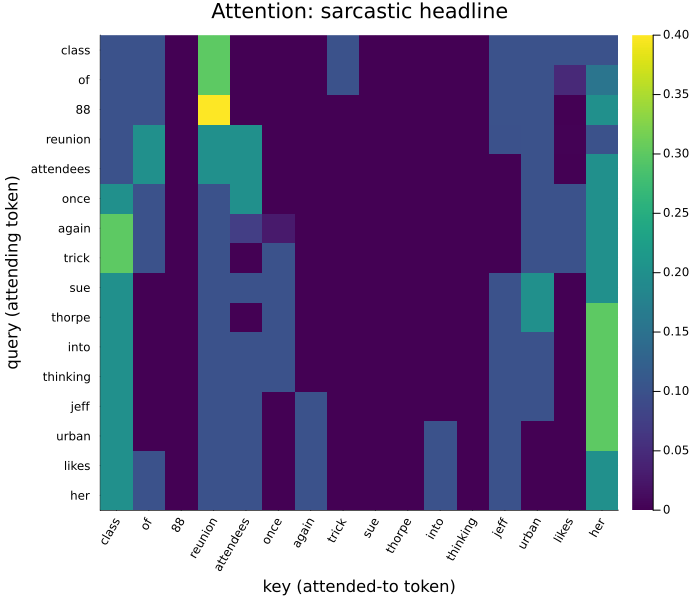

In [18]:
let
    # plot the attention heatmap for the first sarcastic candidate
    si = sarc_candidates[1];
    plot_attention(model,
                   X_test_seq[:, :, si:si],        # single headline token sequence
                   mask_test[:, si:si],             # single headline mask
                   tokens_str[:, TEST_IDX[si]];     # token strings for axis labels
                   title_str="Attention: sarcastic headline")
end

Let's also visualize the attention pattern on a non-sarcastic headline for comparison.

Non-sarcastic headline: how to be superstar sports agent (part two)


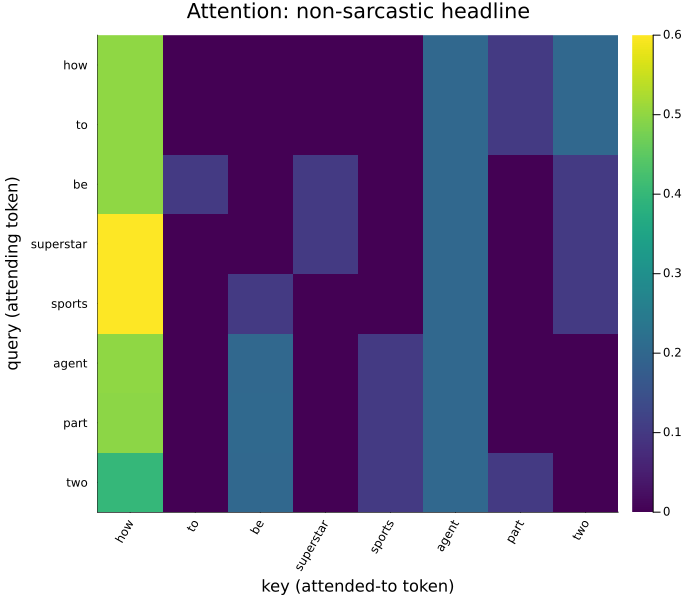

In [19]:
let
    # find a non-sarcastic headline that both models classify correctly
    attn_pred_test = Flux.onecold(model(X_test_seq, mask_test));
    base_pred_test = Flux.onecold(baseline(X_test_mean));
    NOT_SARC_IDX = 1;

    ni = findfirst(i -> test_true[i] == NOT_SARC_IDX &&
                        attn_pred_test[i] == NOT_SARC_IDX &&
                        base_pred_test[i] == NOT_SARC_IDX,
                   1:length(test_true));

    println("Non-sarcastic headline: $(headlines_df.headline[TEST_IDX[ni]])")
    plot_attention(model,
                   X_test_seq[:, :, ni:ni],
                   mask_test[:, ni:ni],
                   tokens_str[:, TEST_IDX[ni]];
                   title_str="Attention: non-sarcastic headline")
end

### Inspecting individual attention heads
Averaging across heads blurs important differences, so let's look at them individually.

* __Independent projections:__ Each head has its own learned $\mathbf{W}_{Q}^{(h)}$, $\mathbf{W}_{K}^{(h)}$, $\mathbf{W}_{V}^{(h)}$ matrices and produces its own attention pattern on the same input.
* __Pattern variety:__ Some heads spread attention broadly (distributing weight evenly across tokens), while others concentrate sharply on one or two key tokens.

We plot heads 1, 2, and 3 for the same sarcastic headline used above.

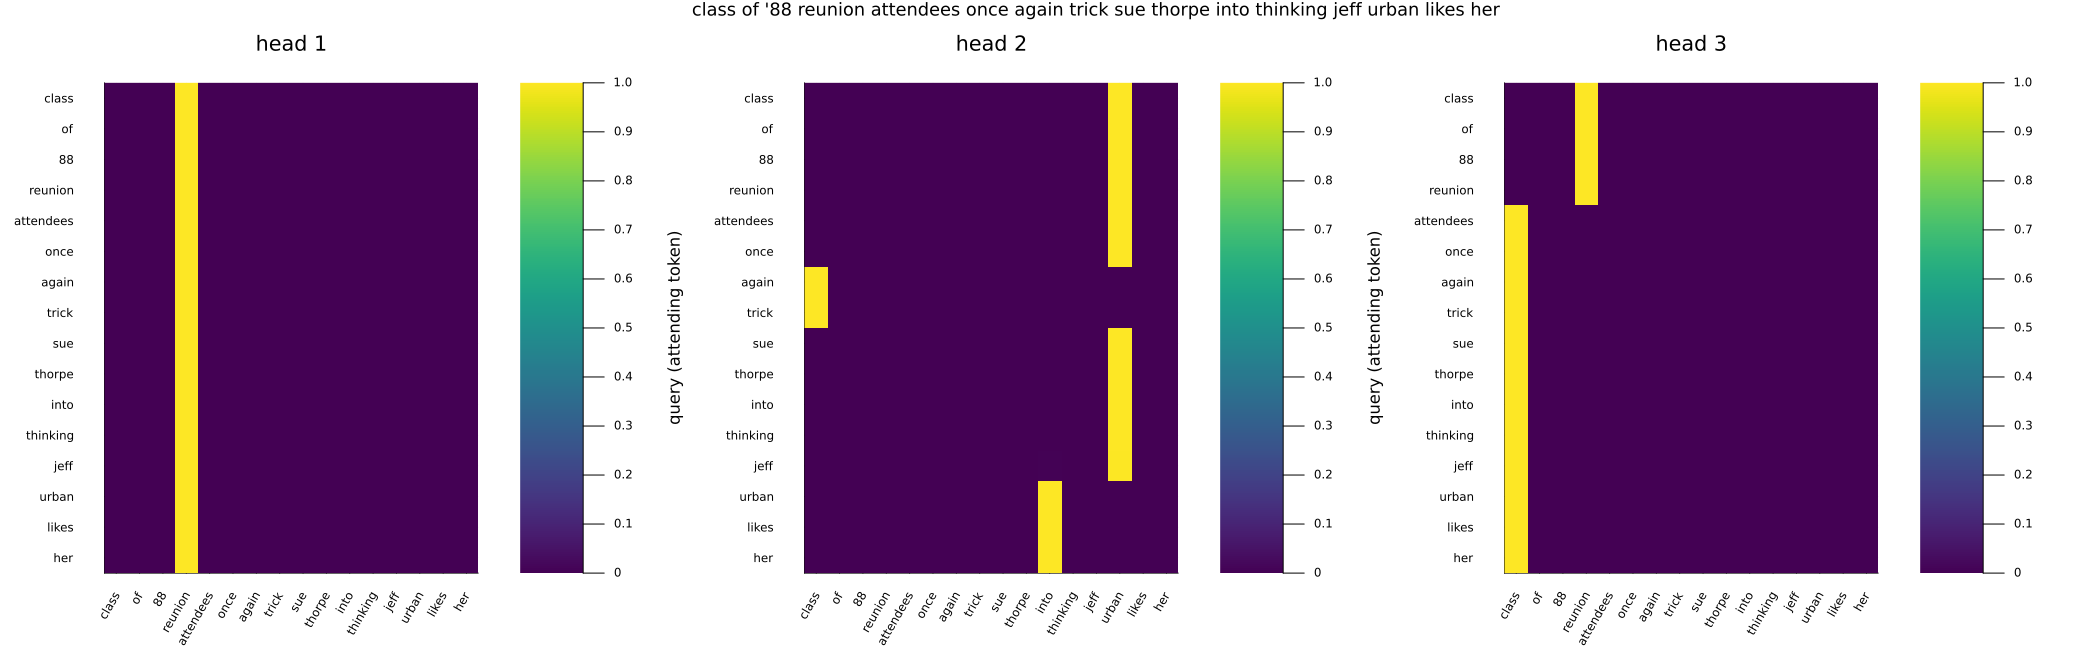

In [20]:
let
    si = sarc_candidates[1];
    X_one = X_test_seq[:, :, si:si];
    mask_one = mask_test[:, si:si];
    toks = tokens_str[:, TEST_IDX[si]];
    headline = headlines_df.headline[TEST_IDX[si]];

    # plot three individual heads side by side; keep per-panel titles short
    # and put the headline on the combined figure via plot_title
    p1 = plot_attention_head(model, X_one, mask_one, toks; head_index=1, title_str="");
    p2 = plot_attention_head(model, X_one, mask_one, toks; head_index=2, title_str="");
    p3 = plot_attention_head(model, X_one, mask_one, toks; head_index=3, title_str="");
    plot(p1, p2, p3; layout=(1, 3), size=(2100, 650),
         plot_title=headline, plot_titlefontsize=12,
         top_margin=8Plots.mm, bottom_margin=8Plots.mm)
end

Compare the three head patterns above. The three heads produce visibly different attention patterns on the same input.

* __Diagonal heads:__ Some heads show a strong diagonal, where each token attends mostly to itself — minimal contextual mixing between positions.
* __Off-diagonal heads:__ Other heads show bright off-diagonal cells, where tokens attend to other tokens at different positions, capturing word-to-word relationships.
* __Why it matters:__ Those off-diagonal patterns are what multi-head attention adds over a single head, since they encode cross-token structure that a mean-pool baseline discards.

You can change the `head_index` values in the cell above (valid range: 1 to 10) to explore all heads.

### Things to think about
* __Does the attention pattern explain the error pattern?__ Using only the attention heatmaps and confusion matrix you already produced in this task (no new code, no retraining): (a) Do sarcastic headlines show visibly different attention patterns from non-sarcastic ones, for example more off-diagonal bright cells or concentration on specific tokens? (b) Does the confusion matrix show more errors on the sarcastic class or the not-sarcastic class? Put the two observations together: does the attention pattern plausibly explain the direction of the error pattern?

___

## Summary
We trained a multi-head self-attention classifier with sinusoidal positional encoding on 28,619 real news headlines from the Sarcasm Headlines Dataset v2 and compared it against a mean-pool baseline on the same 80/20 train/test split.

> __Key Takeaways__:
>
> * **Positional encoding gives self-attention a sense of word order:** Self-attention is permutation-equivariant, meaning it cannot distinguish word order without additional information. Adding sinusoidal positional encoding to the token embeddings provides position information that helps the model detect word-order-dependent patterns like sarcasm.
> * **Multi-head attention captures multiple interaction patterns simultaneously:** Each attention head learns to focus on different token relationships, such as subject-verb incongruity or juxtaposition of formal and absurd language. This gives the model more varied representations than a single attention head while keeping the MLP head the same size as the baseline.
> * **Attention weights provide interpretable sarcasm signals:** Plotting the attention matrix on sarcastic headlines shows which tokens the model focuses on when detecting sarcasm. This interpretability exposes part of the model's decision process that is not available with the mean-pool baseline.

These results show how positional encoding and multi-head attention capture token-level patterns and word-order information that a mean-pool baseline discards, applied to sarcasm detection in news headlines.
___